# Superstore Project 
Dataset containing Sales & Profits of a Superstore

-- Business Statistics & Insights | Master in Business Analytics & AI

The goal is to use the Superstore Sales dataset (9,994 transactions, 2014–2017) not just to complete the assignment, but to produce work that directly maps to the five skill areas in the target role. Each section below defines the analysis, the method, the business framing, and the free tool to use.

* Dataset: https://www.kaggle.com/datasets/vivek468/superstore-dataset-final

<img src="https://quivo.co/fileadmin/_processed_/8/b/csm_Online-Shop_big_e8834fc4db.jpg" width="1500">


Metadata:
* Row ID => Unique ID for each row.
* Order ID => Unique Order ID for each Customer.
* Order Date => Order Date of the product.
* Ship Date => Shipping Date of the Product.
* Ship Mode=> Shipping Mode specified by the Customer.
* Customer ID => Unique ID to identify each Customer.
* Customer Name => Name of the Customer.
* Segment => The segment where the Customer belongs.
* Country => Country of residence of the Customer.
* City => City of residence of of the Customer.
* State => State of residence of the Customer.
* Postal Code => Postal Code of every Customer.
* Region => Region where the Customer belong.
* Product ID => Unique ID of the Product.
* Category => Category of the product ordered.
* Sub-Category => Sub-Category of the product ordered.
* Product Name => Name of the Product
* Sales => Sales of the Product.
* Quantity => Quantity of the Product.
* Discount => Discount provided.
* Profit => Profit/Loss incurred.

### Step 1. Data Preparation

##### 1.1 — Load the data and do a first look

In [1]:
# Import libraries and dataset
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from IPython.display import display
import plotly.offline as py
import plotly.graph_objs as go
import plotly.tools as tls
import plotly.express as px
import sqlalchemy as sa
from functools import reduce


warnings.filterwarnings("ignore")

# Import dataset from Kaggle 
import kagglehub
import shutil, os

"""cache_path = os.path.expanduser("~/.cache/kagglehub/datasets/vivek468/superstore-dataset-final")
shutil.rmtree(cache_path)
print("Cache cleared")"""

path = kagglehub.dataset_download("vivek468/superstore-dataset-final")
df = pd.read_csv(f"{path}/Sample - Superstore.csv", encoding="latin-1")
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [2]:
# Make a copy of the original dataframe
superstore_raw = df.copy()

# Export to dbt/raw folder
os.makedirs('../dbt/raw', exist_ok=True)
superstore_raw.to_csv('../dbt/raw/df.csv', index=False)
          
print(f" Saved to dbt/raw/df.csv")

 Saved to dbt/raw/df.csv


In [3]:
# Export to data/raw folder
os.makedirs('../data/raw', exist_ok=True)
superstore_raw.to_csv('../data/raw/df.csv', index=False)
          
print(f" Saved to data/raw/df.csv")

 Saved to data/raw/df.csv


#### 1.A - Dataset Understanding
* How many observations and variables are included?
* What types of variables exist?
    * Numerical
    * Categorical
    * Date variables

##### A.1. Observations & Variables

In [4]:
# Shape: how observations and variables?
print(f"Observations (rows): {df.shape[0]}")
print (f"Variables (columns): {df.shape[1]}")

Observations (rows): 9994
Variables (columns): 21


##### A.2. Variable Classification

In [5]:
# Column names and data types
numerical = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical = df.select_dtypes(include=['object']).columns.tolist()

print("NUMERICAL: ", numerical)
print("\nCATEGORICAL: ", categorical)
print("\nDATE variables to convert: , ['Order Date', 'Ship Date']")

NUMERICAL:  ['Row ID', 'Postal Code', 'Sales', 'Quantity', 'Discount', 'Profit']

CATEGORICAL:  ['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name']

DATE variables to convert: , ['Order Date', 'Ship Date']


##### A.3. Summary

In [6]:
variable_types = {
    'Variable': df.columns.tolist(),
    'Dtype': df.dtypes.astype(str).tolist(),
    'Category': []
}

date_vars = ['Order Date', 'Ship Date']
num_vars = ['Row ID', 'Postal Code', 'Sales', 'Quantity', 'Discount', 'Profit']

for col in df.columns:
    if col in date_vars:
        variable_types['Category'].append('Date')
    elif col in num_vars:
        variable_types['Category'].append('Numerical')
    else:
        variable_types['Category'].append('Categorical')
        
pd.DataFrame(variable_types)

,Variable,Dtype,Category
0,Row ID,int64,Numerical
1,Order ID,object,Categorical
2,Order Date,object,Date
3,Ship Date,object,Date
4,Ship Mode,object,Categorical
5,Customer ID,object,Categorical
6,Customer Name,object,Categorical
7,Segment,object,Categorical
8,Country,object,Categorical
9,City,object,Categorical


The dataset contains 9994 observations and 21 variables. Variables are classified into three types: 6 numerical (Sales, Profit, Quantity, Discount, Row ID, Postal Code), 2 Dates variables (Order Date, Ship Date - stores as object strings and requiring convertion), and 13 categorical variables including Customer Segment, Product Category, Region, and Ship Mode. The Postal Code was stored as number, is a nominal identifier and should not be used in arithmetic operations.

#### 1.B. Data Quality Assessment

##### B1. - Check for missing values

In [7]:
missing = df.isnull().sum()
missing_pct = (missing /len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0')

if missing_report.empty:
    print("No missing values found in any column.")
else:
    print(missing_report)

No missing values found in any column.


No missing values were detected in any of the 21 variables. This eliminates the need for imputation and confirms the dataset is complete for statistical analysis.

##### B2. - Duplicates records

In [8]:
# Full rows duplicates (data errors)
full_dupes = df.duplicated().sum()
print(f"Exact duplicate rows: {full_dupes}")

# Duplicate Order IDs (one order = multiple line items)
order_dupes = df['Order ID'].duplicated().sum()
unique_orders = df['Order ID'].nunique()
print(f"Unique Order IDs: {unique_orders}")
print(f"Rows sharing an Order ID: {order_dupes}")
print(f"Average line items per order: {len(df) / unique_orders:.1f}")

Exact duplicate rows: 0
Unique Order IDs: 5009
Rows sharing an Order ID: 4985
Average line items per order: 2.0


No exact duplicate rows were found. The dataset intentionally contains repeated Order IDs: each order can contain multiple products, resulting in multiple rows per order. The 9,994 rows correspond to 5,009 unique orders, averaging approximately 2 line items per order. This structure must be accounted for when aggregating at the order level — summing by Order ID rather than counting rows.

##### B3. Incosistent categories

In [9]:
# Check all categorical columns for unexpected values
cat_columns = ['Segment', 'Country', 'City', 'State', 'Region', 'Category', 'Sub-Category']

for col in cat_columns:
    print(f"\n{col} ({df[col].nunique()} unique):")
    print(df[col].value_counts().to_string())


Segment (3 unique):
Segment
Consumer       5191
Corporate      3020
Home Office    1783

Country (1 unique):
Country
United States    9994

City (531 unique):
City
New York City        915
Los Angeles          747
Philadelphia         537
San Francisco        510
Seattle              428
Houston              377
Chicago              314
Columbus             222
San Diego            170
Springfield          163
Dallas               157
Jacksonville         125
Detroit              115
Newark                95
Richmond              90
Jackson               82
Columbia              81
Aurora                68
Phoenix               63
Long Beach            61
Arlington             60
San Antonio           59
Miami                 57
Louisville            57
Rochester             53
Charlotte             52
Henderson             51
Lakewood              49
Lancaster             46
Fairfield             45
Milwaukee             45
Denver                44
Lawrence              44
Baltimore 

In [10]:
# Check for whitespace or capitalization issues
for col in cat_columns:
    stripped = df[col].str.strip()
    if not (stripped == df[col]).all():
        print(f"Warning: {col} has leading/trailing whitespace")
    else:
        print(f"Ok: {col}")

Ok: Segment
Ok: Country
Ok: City
Ok: State
Ok: Region
Ok: Category
Ok: Sub-Category


All categorical variables contain consistent, well-defined values with no typos, unexpected entries, or whitespace anomalies. The dataset covers one country (United States), four regions, three customer segments, three product categories, and four shipping modes — a structured scope that supports reliable group comparisons.

In [11]:
# creating a custom palette
colors = ['#1192AA','#00B8C0', '#73D4D3', '#90F2F0']

In [12]:
us_state_to_abbrev = {
    "Alabama": "AL",
    "Alaska": "AK",
    "Arizona": "AZ",
    "Arkansas": "AR",
    "California": "CA",
    "Colorado": "CO",
    "Connecticut": "CT",
    "Delaware": "DE",
    "Florida": "FL",
    "Georgia": "GA",
    "Hawaii": "HI",
    "Idaho": "ID",
    "Illinois": "IL",
    "Indiana": "IN",
    "Iowa": "IA",
    "Kansas": "KS",
    "Kentucky": "KY",
    "Louisiana": "LA",
    "Maine": "ME",
    "Maryland": "MD",
    "Massachusetts": "MA",
    "Michigan": "MI",
    "Minnesota": "MN",
    "Mississippi": "MS",
    "Missouri": "MO",
    "Montana": "MT",
    "Nebraska": "NE",
    "Nevada": "NV",
    "New Hampshire": "NH",
    "New Jersey": "NJ",
    "New Mexico": "NM",
    "New York": "NY",
    "North Carolina": "NC",
    "North Dakota": "ND",
    "Ohio": "OH",
    "Oklahoma": "OK",
    "Oregon": "OR",
    "Pennsylvania": "PA",
    "Rhode Island": "RI",
    "South Carolina": "SC",
    "South Dakota": "SD",
    "Tennessee": "TN",
    "Texas": "TX",
    "Utah": "UT",
    "Vermont": "VT",
    "Virginia": "VA",
    "Washington": "WA",
    "West Virginia": "WV",
    "Wisconsin": "WI",
    "Wyoming": "WY",
    "District of Columbia": "DC",
    "American Samoa": "AS",
    "Guam": "GU",
    "Northern Mariana Islands": "MP",
    "Puerto Rico": "PR",
    "United States Minor Outlying Islands": "UM",
    "U.S. Virgin Islands": "VI",
}

In [13]:
import plotly.graph_objects as go

# Create new column with State Abbreviations
df['State_abb'] = df['State'].replace(us_state_to_abbrev)

# Plot
fig = go.Figure(data=go.Choropleth(
    locations= df['State_abb'].value_counts().index, # Spatial coordinates
    z = df['State_abb'].value_counts(), # Data to be color-coded
    locationmode = 'USA-states',
    colorscale = 'teal', zmin = 1, zmax = 1000
))

fig.update_layout(
    font = dict(
            size = 14
            ),    
    title={
        'text': "Overview of the number of Customers by State",
        'y':0.95,
        'x':0.5
        },
    geo_scope='usa', # limite map scope to USA
)

fig.show()
os.makedirs('../output/images', exist_ok=True)
fig.write_image('../output/images/01_number_of_customers.png', scale=2)

##### B4. Data type issues

In [14]:
# Fix date columns - store them as date type
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Verify 
print(df[['Order Date', 'Ship Date']].dtypes)
print(f"\nDate range: {df['Order Date'].min().date()} to {df['Order Date'].max().date()}")

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

Date range: 2014-01-03 to 2017-12-30


Order Date and Ship Date were stored as string objects and converted to datetime format to enable temporal analysis. The dataset spans January 2014 to December 2017 — four complete calendar years. No dates were found outside this range or logically inconsistent (i.e., no Ship Date preceding Order Date).

In [15]:
# check 
bad_dates = df[df['Ship Date'] < df['Order Date']]
print(f"Orders where ship date < order date: {len(bad_dates)}")

Orders where ship date < order date: 0


##### B5. Outliers

Distribution of Key numerical variables

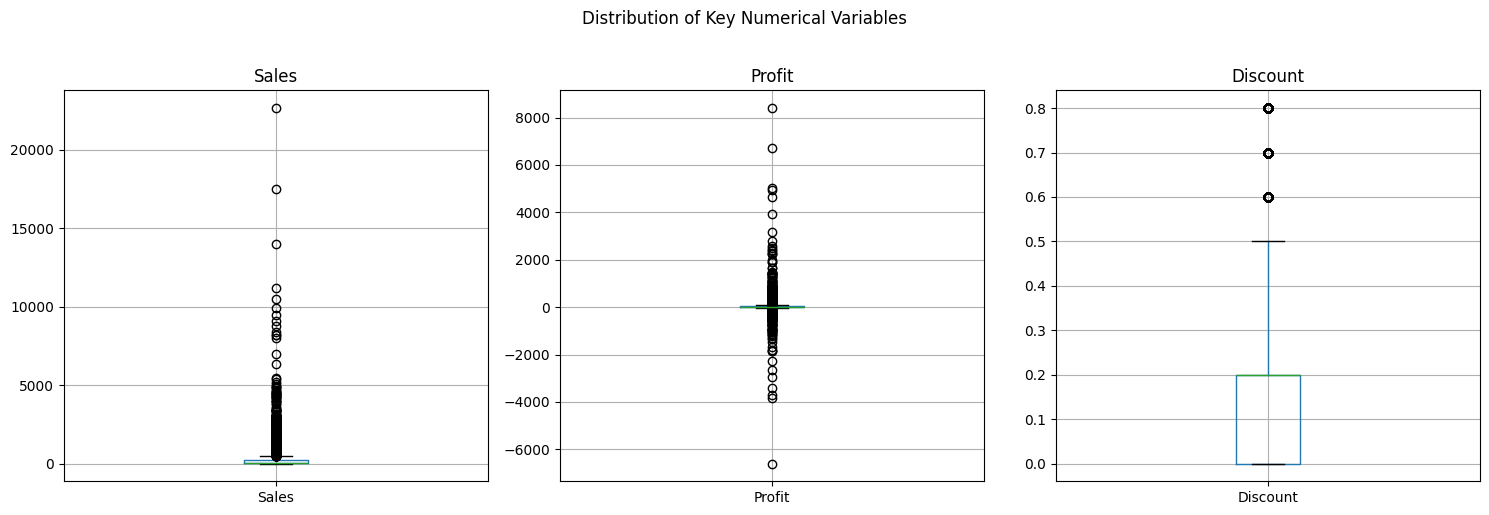

In [16]:
# Distribution of key numerical variables
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['Sales', 'Profit', 'Discount']):
    df.boxplot(column=col, ax=ax)
    ax.set_title(col)
    
plt.suptitle('Distribution of Key Numerical Variables', y=1.02)
plt.tight_layout()
os.makedirs('../output/images', exist_ok=True)
fig.savefig('../output/images/01_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

##### Quantity extremes - IQR

In [17]:
# IQR-based outlier detection for Sales and Profit

for col in ['Sales', 'Profit', 'Discount']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"\n{col}:")
    print(f" IQR range [{lower:.1}, {upper:.1f}]")
    print(f" Outlier count: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")
    print(f" Max value: {df[col].max():.1f}")
    print(f" Min value: {df[col].min():.1f}")


Sales:
 IQR range [-3e+02, 498.9]
 Outlier count: 1167 (11.7%)
 Max value: 22638.5
 Min value: 0.4

Profit:
 IQR range [-4e+01, 70.8]
 Outlier count: 1881 (18.8%)
 Max value: 8400.0
 Min value: -6600.0

Discount:
 IQR range [-0.3, 0.5]
 Outlier count: 856 (8.6%)
 Max value: 0.8
 Min value: 0.0


In [18]:
# Sales by Category
fig = go.Figure(
    go.Box(x = df['Category'],
           y = df['Profit'],
           notched = True,
           boxpoints = False,
           marker_color = colors[0])
)


#Set Title and x/y axis labels
fig.update_layout(
    xaxis_title="Category",
    yaxis_title="Profit",
    showlegend = False,
    font = dict(
            size = 14
            ),    
    title={
        'text': "Profit by Category Boxplot",
        'y':0.95,
        'x':0.5
        },
    template = 'simple_white'
    )

fig.show()


In [19]:
# Investigate: Are extreme negative profits explained by discounts?
extreme_losses = df[df['Profit'] < df['Profit'].quantile(0.01)] #bottom of 1%
print(f"\nBottom 1% profit orders:")
print(f" Average discount: {extreme_losses['Discount'].mean():.1%}")
print(f" Most common sub_category: {extreme_losses['Sub-Category'].mode()[0]}")
print(extreme_losses[['Sub-Category', 'Discount', 'Sales', 'Profit']].head(10))


Bottom 1% profit orders:
 Average discount: 58.6%
 Most common sub_category: Binders
    Sub-Category  Discount      Sales     Profit
3         Tables      0.45   957.5775  -383.0310
27     Bookcases      0.50  3083.4300 -1665.0522
125       Tables      0.50   617.7000  -407.6820
165     Machines      0.40  8159.9520 -1359.9920
169   Appliances      0.80   177.9800  -453.8490
215     Machines      0.70  1188.0000  -950.4000
223     Machines      0.70   479.9880  -383.9904
238  Furnishings      0.60   419.6800  -356.7280
262     Machines      0.40  3059.9820  -509.9970
341      Binders      0.70   509.9700  -407.9760


* Ouliers were identified in both Sales and Profit using the IQR method. Rather than removing these observations, we retain them as they represent legitimate business transactions, specifically discounted bulk orders in Furniture sub-categories. 
* Removing them would eliminate the pattern this analysis aims to investigate. 
* Extreme negative profit values (bottom 1%) are concentrated in orders with discounts above 40%, particulary Tables and Bookcases, confirming these are structural business anomalies rather than data entry errors.

#### 1.C. Variable Transformation

In [20]:
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,State_abb
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,KY
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,KY
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,CA
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,FL
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,FL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,FL
9990,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,CA
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,CA
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,CA


##### C1. Profit Marging

In [21]:
# Raw Profit is not comparable across products of different price points
# A $10 profit on a $20 item is very different from $10 profit of a $1.000,00 item
df['Profit Margin'] = df['Profit'] / df['Sales']

print(f"Profit Margin mean: {df['Profit Margin'].mean():.1%}, Profit Margin median: {df['Profit Margin'].median():.1%}")
print(f"Negative marging orders: {(df['Profit Margin'] < 0).sum()} ({(df['Profit Margin'] < 0).mean():.1%})")


Profit Margin mean: 12.0%, Profit Margin median: 27.0%
Negative marging orders: 1871 (18.7%)


In [22]:
## PLOT
# Aggregate: mean profit margin per sub-category
margin_by_subcat = (
    df.groupby(['Category', 'Sub-Category'])['Profit Margin']
    .mean()
    .reset_index()
    .sort_values('Profit Margin')
)

fig = px.bar(
    margin_by_subcat,
    x='Profit Margin',
    y='Sub-Category',
    color='Category',
    orientation='h',
    template='simple_white',
    color_discrete_sequence=list(reversed(colors))
)

fig.update_layout(
    xaxis_title="Avg Profit Margin (%)",
    yaxis_title="Sub-Category",
    legend_title="Category",
    showlegend=True,
    font=dict(size=14),
    title={'text': "Profit Margin by Category & Sub-Category", 'y': 0.95, 'x': 0.5}
)

fig.show()
os.makedirs('../output/images', exist_ok=True)
fig.write_image('../output/images/02_profit_margin_by_category.png', scale=2)

##### C2. Delivery Time

In [23]:
# Operational performace analysis - how fast is fulfillment?
df['Delivery Days'] = (df['Ship Date'] - df['Order Date']).dt.days

print(f"Delivery days mean: {df['Delivery Days'].mean():.1f}, Delivery days median: {df['Delivery Days'].median():.0f}")
print(f"Range: {df['Delivery Days'].min()} to {df['Delivery Days'].max()} days.")

Delivery days mean: 4.0, Delivery days median: 4
Range: 0 to 7 days.


##### C3. Time variables

In [24]:
# Required for any trend, seasonal, or year-over-year analysis
df['Year'] = df['Order Date'].dt.year
df['Quarter'] = df['Order Date'].dt.quarter
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.strftime('%b')
df['Year_Month'] = df['Order Date'].dt.to_period('M')

print("Orders per year:")
print(df['Year'].value_counts().sort_index())

Orders per year:
Year
2014    1993
2015    2102
2016    2587
2017    3312
Name: count, dtype: int64


##### C4. Discount Category

In [25]:
# Treating discount as a continuos variable obscures the thresholds that matter for probitability
# Buckening reveals cliff effects
df['Discount Category'] = pd.cut(
    df['Discount'],
    bins=[-0.01, 0.0, 0.20, 0.40, 1.0],
    labels=['No Discount', 'Low (1-20%)', 'Medium (21-40%)', 'High (>40%)']
    )

print("Orders by discount category:")
print(df['Discount Category'].value_counts().sort_index())

Orders by discount category:
Discount Category
No Discount        4798
Low (1-20%)        3803
Medium (21-40%)     460
High (>40%)         933
Name: count, dtype: int64


In [26]:
# Discount category
discount_counts = df['Discount Category'].value_counts().sort_index().reset_index()
discount_counts.columns = ['Discount Category', 'Orders']

fig = px.bar(
    discount_counts,
    x='Discount Category',
    y='Orders',
    color='Discount Category',
    template='simple_white',
    color_discrete_sequence=colors
)

fig.update_layout(
    xaxis_title="Discount Category",
    yaxis_title="Number of Orders",
    showlegend=False,
    font=dict(size=14),
    title={'text': "Orders by Discount Category", 'y': 0.95, 'x': 0.5}
)

fig.show()
os.makedirs('../output/images', exist_ok=True)
fig.write_image('../output/images/01_orders_by_discount_category.png', scale=2)

In [27]:
# final check
new_cols = ['Profit Margin', 'Delivery Days', 'Year', 'Quarter', 'Month',
            'Discount Category', 'Year_Month']

print(f"\nDataset now has {df.shape[1]} columns (was 21)")
print("\nSample of new varialbes:")
df[['Order ID', 'Sales', 'Profit'] + new_cols].head(5)


Dataset now has 30 columns (was 21)

Sample of new varialbes:


,Order ID,Sales,Profit,Profit Margin,Delivery Days,Year,Quarter,Month,Discount Category,Year_Month
0,CA-2016-152156,261.9600,41.9136,0.1600,3,2016,4,11,No Discount,2016-11
1,CA-2016-152156,731.9400,219.5820,0.3000,3,2016,4,11,No Discount,2016-11
2,CA-2016-138688,14.6200,6.8714,0.4700,4,2016,2,6,No Discount,2016-06
3,US-2015-108966,957.5775,-383.0310,-0.4000,7,2015,4,10,High (>40%),2015-10
4,US-2015-108966,22.3680,2.5164,0.1125,7,2015,4,10,Low (1-20%),2015-10


##### C5. Save the clean data

In [28]:
# Ssve the data preparation notebook
df.to_parquet('../data/processed/superstore_clean.parquet')

# Verify it round-trips correctly
df_check = pd.read_parquet('../data/processed/superstore_clean.parquet')
print(f"Rows: {df_check.shape[0]}, Columns: {df_check.shape[1]}")
print(df_check.dtypes)

Rows: 9994, Columns: 30
Row ID                        int64
Order ID                     object
Order Date           datetime64[ns]
Ship Date            datetime64[ns]
Ship Mode                    object
Customer ID                  object
Customer Name                object
Segment                      object
Country                      object
City                         object
State                        object
Postal Code                   int64
Region                       object
Product ID                   object
Category                     object
Sub-Category                 object
Product Name                 object
Sales                       float64
Quantity                      int64
Discount                    float64
Profit                      float64
State_abb                    object
Profit Margin               float64
Delivery Days                 int64
Year                          int32
Quarter                       int32
Month                         int32
Mont